In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../../../Data/HousingData.csv")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [3]:
df.isnull().mean()

CRIM       0.039526
ZN         0.039526
INDUS      0.039526
CHAS       0.039526
NOX        0.000000
RM         0.000000
AGE        0.039526
DIS        0.000000
RAD        0.000000
TAX        0.000000
PTRATIO    0.000000
B          0.000000
LSTAT      0.039526
MEDV       0.000000
dtype: float64

In [4]:
df.dropna(inplace=True)

In [5]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 🌳 Decision Tree Regressor Parameters

### **criterion** `{“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}` *(default = “squared_error”)*

Function to measure the quality of a split:

* **squared_error** → Mean Squared Error (variance reduction, L2 loss)
* **friedman_mse** → MSE with Friedman improvement score
* **absolute_error** → Mean Absolute Error (L1 loss, median of node)
* **poisson** → Half mean Poisson deviance reduction

---

### **splitter** `{“best”, “random”}` *(default = “best”)*

Strategy used to choose splits:

* **best** → Optimal split
* **random** → Best random split

---

### **max_depth** `int` *(default = None)*

Maximum depth of the tree:

* **None** → Expand until all leaves are pure or have < `min_samples_split`
* Controls **model complexity** and overfitting

---

### **min_samples_split** `int or float` *(default = 2)*

Minimum samples required to split an internal node:

* **int** → Minimum number of samples
* **float** → Fraction of total samples (`ceil(min_samples_split * n_samples)`)

---

### **min_samples_leaf** `int or float` *(default = 1)*

Minimum samples required at a leaf node:

* Ensures each split leaves enough samples
* Helps **smooth the model**, especially in regression

---

### **min_weight_fraction_leaf** `float` *(default = 0.0)*

Minimum weighted fraction of total sample weights required at a leaf node.

* Equal weights assumed if `sample_weight` is not provided

---

### **max_features** `int, float, {“sqrt”, “log2”}` *(default = None)*

Number of features considered at each split:

* **int** → Fixed number
* **float** → Fraction of features
* **sqrt** → √(total features)
* **log2** → log₂(total features)
* **None** → All features

> Note: At least one valid split is always found even if more than `max_features` are checked

---

### **random_state** `int or RandomState` *(default = None)*

Controls randomness:

* Random feature permutation at each split
* Ensures reproducibility if fixed

---

### **max_leaf_nodes** `int` *(default = None)*

Maximum number of leaf nodes:

* Tree grows in **best-first fashion**
* **None** → Unlimited leaf nodes

---

### **min_impurity_decrease** `float` *(default = 0.0)*

A node is split only if impurity decreases by at least this value

**Weighted impurity decrease:**

```text
(N_t / N) * (impurity 
             - (N_t_R / N_t * right_impurity) 
             - (N_t_L / N_t * left_impurity))
```

Where:

* `N` = total samples
* `N_t` = samples at current node
* `N_t_L`, `N_t_R` = samples in left & right child

Weighted sums used if `sample_weight` is provided

---

### **ccp_alpha** `float ≥ 0` *(default = 0.0)*

Complexity parameter for **Minimal Cost-Complexity Pruning**:

* Higher → More pruning
* Default → No pruning

---

### **monotonic_cst** `array-like of int` *(default = None)*

Monotonicity constraints per feature:

* `1` → Increasing
* `0` → No constraint
* `-1` → Decreasing

⚠️ Not supported for:

* Multi-output regression
* Regression with missing values

---


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
y_pred = dt_reg.predict(X_test)
r2_score(y_test, y_pred)

0.6271705013111171

In [8]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(DecisionTreeRegressor(),X,y,scoring='r2',cv=5))

np.float64(0.1912591606351055)

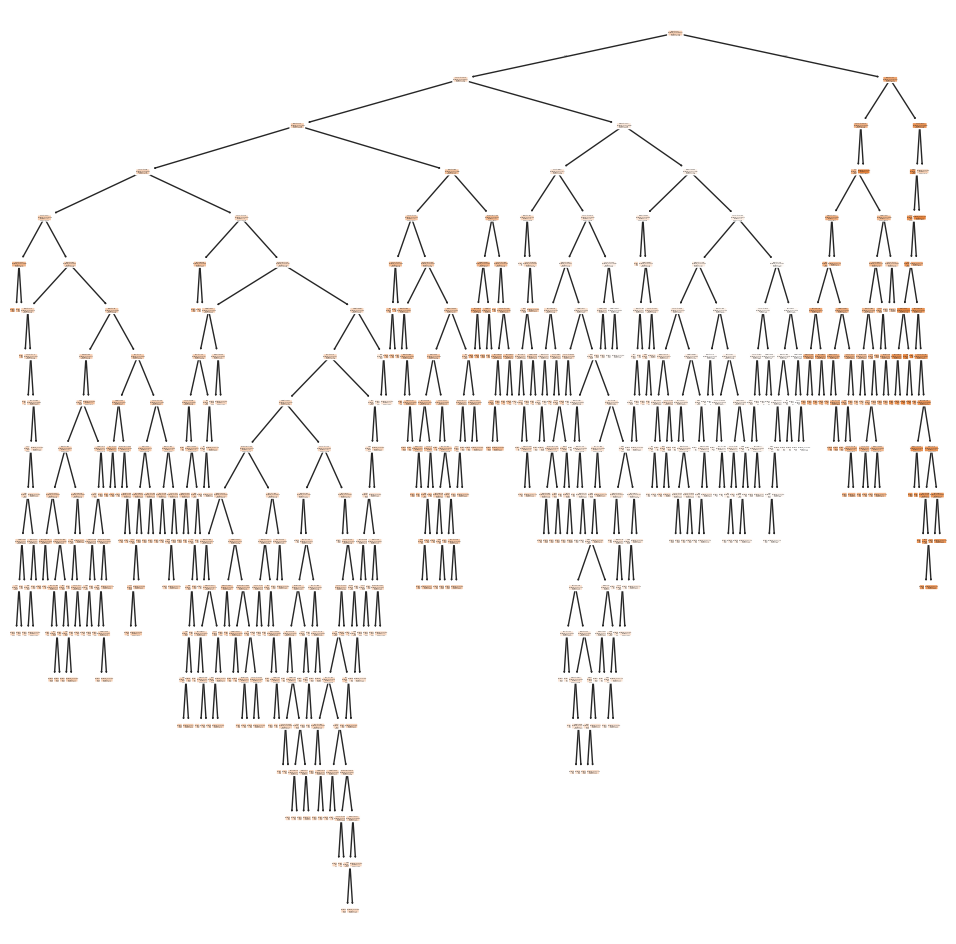

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,12))
plot_tree(dt_reg, filled=True, feature_names=X.columns, rounded=True)
plt.show()